In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [60]:

df = pd.read_csv("datasets/train.csv")
df.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,...,JobTenure,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,RiskScore
0,2010-06-26,27.0,66829.0,549.0,17290.0,60.0,Divorced,1.0,Rent,1095.0,...,4.0,Employed,Associate,4.0,35067.0,0.257790,0.251465,508.970230,0.288013,66.176500
1,1996-09-23,55.0,172147.0,850.0,16110.0,36.0,Widowed,1.0,Mortgage,211.0,...,2.0,Employed,High School,33.0,27001.0,0.086110,0.093173,514.675859,0.050585,28.495737
2,2015-01-19,51.0,300000.0,850.0,38436.0,36.0,Married,0.0,Mortgage,546.0,...,3.0,Employed,Bachelor,28.0,278382.0,0.108436,0.115443,1268.276385,0.072571,34.488104
3,1981-05-12,25.0,34683.0,847.0,19186.0,48.0,Married,0.0,Other,153.0,...,3.0,Employed,High School,0.0,9224.0,0.100686,0.112822,498.505187,0.225415,36.910753
4,1995-05-07,55.0,300000.0,850.0,30437.0,48.0,Single,2.0,Rent,562.0,...,5.0,Employed,Bachelor,31.0,4502.0,0.110437,0.089037,756.035156,0.052721,31.347091


## EDA

In [61]:
print("\nСтруктура датасета:")
print(df.info())



Структура датасета:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11017 entries, 0 to 11016
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             10487 non-null  object 
 1   Age                         10487 non-null  float64
 2   AnnualIncome                10487 non-null  float64
 3   CreditScore                 9986 non-null   float64
 4   LoanAmount                  9986 non-null   float64
 5   LoanDuration                10487 non-null  float64
 6   MaritalStatus               10487 non-null  object 
 7   NumberOfDependents          10487 non-null  float64
 8   HomeOwnershipStatus         10487 non-null  object 
 9   MonthlyDebtPayments         9986 non-null   float64
 10  CreditCardUtilizationRate   10487 non-null  float64
 11  NumberOfOpenCreditLines     10487 non-null  float64
 12  NumberOfCreditInquiries     10487 non-null  float64
 13  DebtToInco

In [62]:
print("\nПроверка на пропуски в данных:")
df.isnull().sum()


Проверка на пропуски в данных:


ApplicationDate                530
Age                            530
AnnualIncome                   530
CreditScore                   1031
LoanAmount                    1031
LoanDuration                   530
MaritalStatus                  530
NumberOfDependents             530
HomeOwnershipStatus            530
MonthlyDebtPayments           1031
CreditCardUtilizationRate      530
NumberOfOpenCreditLines        530
NumberOfCreditInquiries        530
DebtToIncomeRatio              530
BankruptcyHistory             1031
LoanPurpose                   1031
PreviousLoanDefaults           530
PaymentHistory                 530
LengthOfCreditHistory          530
SavingsAccountBalance          530
CheckingAccountBalance        1031
TotalAssets                   1031
TotalLiabilities               530
MonthlyIncome                  530
UtilityBillsPaymentHistory     530
JobTenure                      530
EmploymentStatus               530
EducationLevel                 530
Experience          

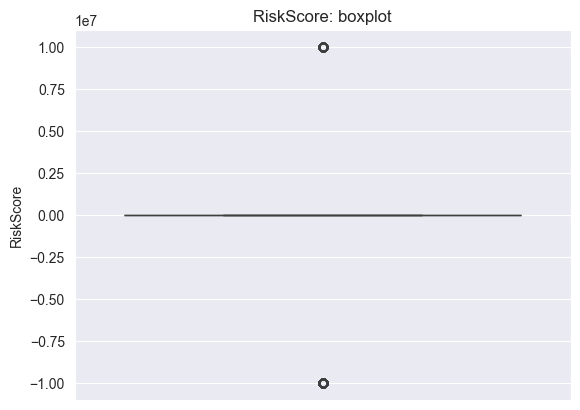

In [63]:
fig = sns.boxplot(df["RiskScore"])
fig.set_title("RiskScore: boxplot")
plt.show()


    Можно заметить 2 существенных выброса, которые нужно отбросить

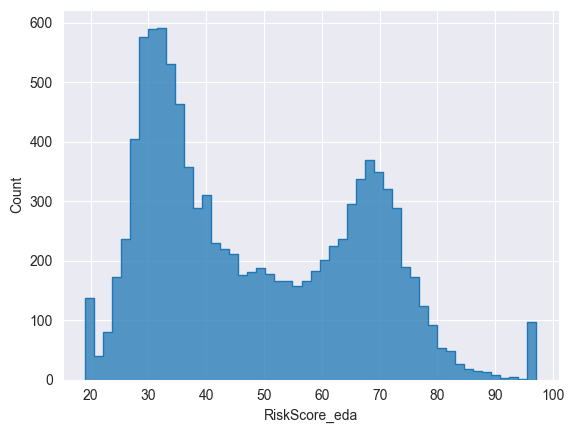

In [64]:
eda = df.copy()

y = pd.to_numeric(eda["RiskScore"], errors="coerce").replace([np.inf, -np.inf], np.nan)
low, high = y.quantile(
    [0.012, 0.991]
)  
eda["RiskScore_eda"] = y.clip(lower=low, upper=high)

sns.histplot(eda["RiskScore_eda"].dropna(), bins=50, element="step")
plt.show()

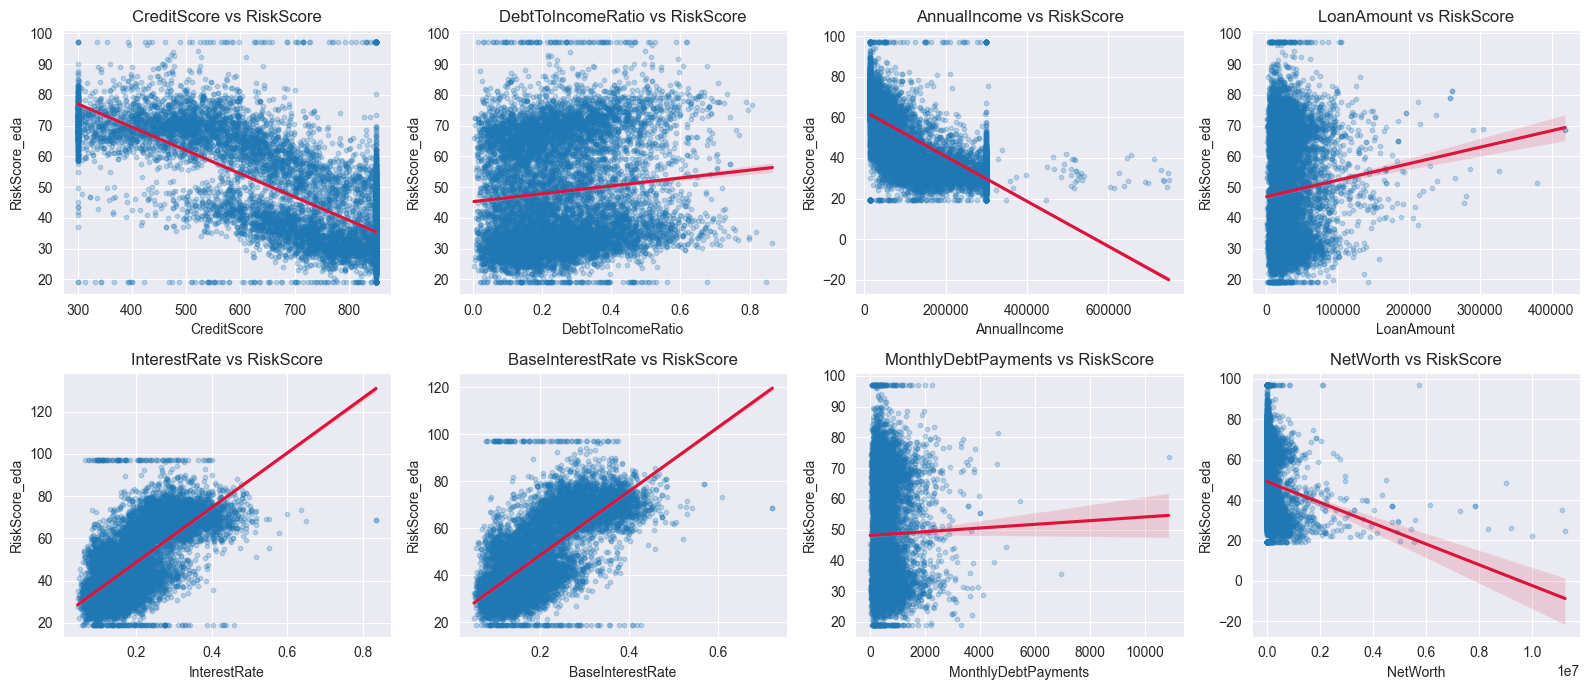

In [65]:
num_cols = [
    "CreditScore",
    "DebtToIncomeRatio",
    "AnnualIncome",
    "LoanAmount",
    "InterestRate",
    "BaseInterestRate",
    "MonthlyDebtPayments",
    "NetWorth",
]
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), num_cols):
    x = pd.to_numeric(df[col], errors="coerce").replace([np.inf, -np.inf], np.nan)
    sns.regplot(
        x=x,
        y=eda["RiskScore_eda"],
        scatter_kws={"alpha": 0.25, "s": 10},
        line_kws={"color": "crimson"},
        ax=ax,
    )
    ax.set_title(f"{col} vs RiskScore")
plt.tight_layout()
plt.show()


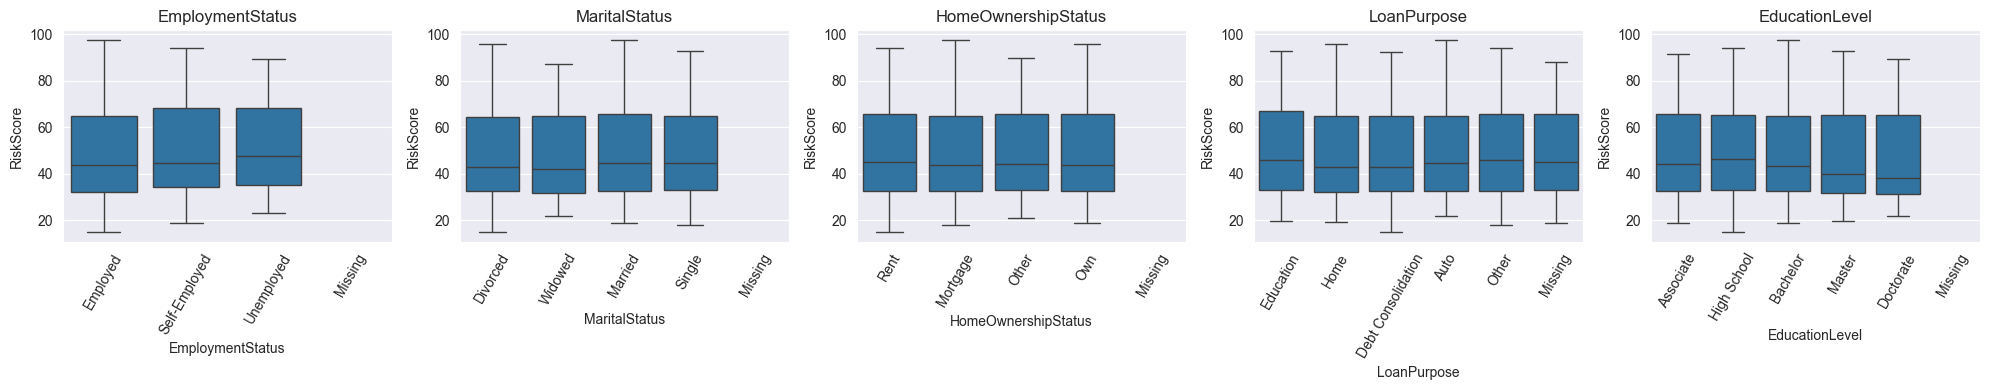

In [66]:
cat_cols = [
    "EmploymentStatus",
    "MaritalStatus",
    "HomeOwnershipStatus",
    "LoanPurpose",
    "EducationLevel",
]
fig, axes = plt.subplots(1, len(cat_cols), figsize=(4 * len(cat_cols), 4))
for ax, col in zip(axes, cat_cols):
    s = df[col].fillna("Missing")
    sns.boxplot(x=s, y=y, showfliers=False, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.show()

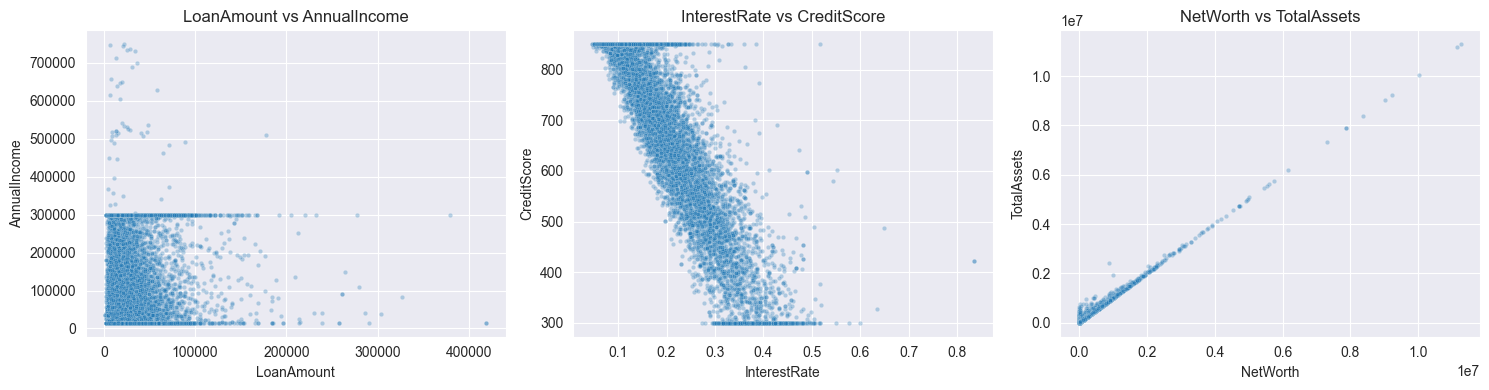

In [67]:
pairs = [
    ("LoanAmount", "AnnualIncome"),
    ("InterestRate", "CreditScore"),
    ("NetWorth", "TotalAssets"),
]
fig, axes = plt.subplots(1, len(pairs), figsize=(5 * len(pairs), 4))
for ax, (a, b) in zip(axes, pairs):
    xa = pd.to_numeric(df[a], errors="coerce")
    xb = pd.to_numeric(df[b], errors="coerce")
    sns.scatterplot(x=xa, y=xb, s=10, alpha=0.3, ax=ax)
    ax.set_title(f"{a} vs {b}")
plt.tight_layout()
plt.show()

<Axes: >

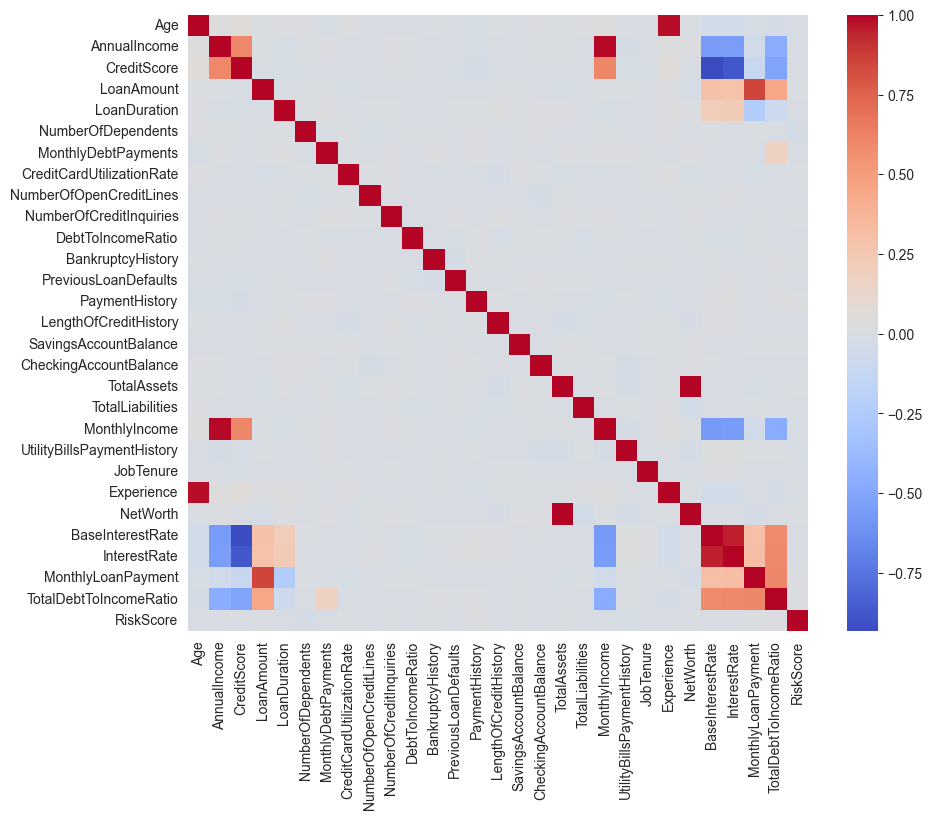

In [68]:
num = df.select_dtypes("number").replace([np.inf,-np.inf], np.nan)
num_f = num.apply(lambda s: s.fillna(s.median()))
corr = num_f.corr()
plt.figure(figsize = (10,8))
sns.heatmap(corr, cmap="coolwarm")

In [69]:
print(df["RiskScore"].describe())
print(df["RiskScore"].value_counts().head(10))

count    1.048700e+04
mean    -2.569878e+04
std      1.431675e+06
min     -9.999999e+06
25%      3.256475e+01
50%      4.411876e+01
75%      6.535690e+01
max      1.000000e+07
Name: RiskScore, dtype: float64
RiskScore
-9.999999e+06    121
 1.000000e+07     94
 6.554056e+01      3
 6.785041e+01      3
 3.513328e+01      3
 6.495533e+01      3
 3.704447e+01      3
 7.801113e+01      3
 5.040845e+01      3
 6.485634e+01      3
Name: count, dtype: int64


In [70]:
low_q = df["RiskScore"].quantile(0.012)
high_q = df["RiskScore"].quantile(0.991)
df_trimmed = df[(df["RiskScore"] >= low_q) & (df["RiskScore"] <= high_q)]

# 2. Очистка NaN по таргету
target = "RiskScore"
id_cols = ["Id"]
valid_mask = df_trimmed[target].notna()
df_clean = df_trimmed[valid_mask].reset_index(drop=True)

# 3. Базовые числовые признаки
num_cols = df_clean.select_dtypes(include=["number"]).columns.tolist()
num_cols = [c for c in num_cols if c not in [target] + id_cols]

# 4. Категориальные признаки (строки)
cat_cols = [
    "MaritalStatus",
    "EmploymentStatus",
    "EducationLevel",
    "LoanPurpose",
    "HomeOwnershipStatus",
]

In [71]:
# 5. Feature engineering (перед OHE)
df_fe = df_clean.copy()

df_fe["ApplicationDate"] = pd.to_datetime(df_fe["ApplicationDate"])
df_fe["AppYear"] = df_fe["ApplicationDate"].dt.year
df_fe["AppMonth"] = df_fe["ApplicationDate"].dt.month

min_date = df_fe["ApplicationDate"].min()
df_fe["AppDaysSinceMin"] = (df_fe["ApplicationDate"] - min_date).dt.days

df_fe["Income_per_person"] = df_fe["AnnualIncome"] / (df_fe["NumberOfDependents"] + 1)

df_fe["Liabilities_to_Income"] = df_fe["TotalLiabilities"] / (df_fe["AnnualIncome"] + 1)
df_fe["Assets_to_Income"] = df_fe["TotalAssets"] / (df_fe["AnnualIncome"] + 1)
df_fe["Savings_to_Income"] = df_fe["SavingsAccountBalance"] / (
    df_fe["AnnualIncome"] + 1
)
df_fe["Checking_to_Income"] = df_fe["CheckingAccountBalance"] / (
    df_fe["AnnualIncome"] + 1
)

# ежемесячные долговые платежи относительно месячного дохода
df_fe["MonthlyDebt_to_Income"] = df_fe["MonthlyDebtPayments"] / (
    df_fe["MonthlyIncome"] + 1
)

df_fe["log_Savings"] = np.log1p(df_fe["SavingsAccountBalance"].clip(lower=0))
df_fe["log_Checking"] = np.log1p(df_fe["CheckingAccountBalance"].clip(lower=0))
df_fe["log_Assets"] = np.log1p(df_fe["TotalAssets"].clip(lower=0))
df_fe["log_Liabilities"] = np.log1p(df_fe["TotalLiabilities"].clip(lower=0))

df_fe["Interest_Spread"] = df_fe["InterestRate"] - df_fe["BaseInterestRate"]

df_fe["High_CardUtil"] = (df_fe["CreditCardUtilizationRate"] > 0.8).astype(int)
df_fe["Short_CreditHistory"] = (df_fe["LengthOfCreditHistory"] < 12).astype(int)
df_fe["Many_Inquiries"] = (df_fe["NumberOfCreditInquiries"] >= 5).astype(int)


df_fe["Age_squared"] = df_fe["Age"] ** 2
df_fe["CreditScore_squared"] = df_fe["CreditScore"] ** 2
df_fe["DebtToIncome_squared"] = df_fe["DebtToIncomeRatio"] ** 2
df_fe["LoanAmount_squared"] = df_fe["LoanAmount"] ** 2

df_fe["Age_x_Income"] = df_fe["Age"] * df_fe["AnnualIncome"]
df_fe["CreditScore_x_Income"] = df_fe["CreditScore"] * df_fe["AnnualIncome"]
df_fe["LoanAmount_x_Duration"] = df_fe["LoanAmount"] * df_fe["LoanDuration"]
df_fe["CreditScore_x_DebtRatio"] = df_fe["CreditScore"] * df_fe["DebtToIncomeRatio"]

df_fe["MonthlyPayment_to_Income"] = df_fe["MonthlyLoanPayment"] / (
    df_fe["MonthlyIncome"] + 1
)
df_fe["LoanAmount_to_Income"] = df_fe["LoanAmount"] / (df_fe["AnnualIncome"] + 1)
df_fe["NetWorth_to_Income"] = df_fe["NetWorth"] / (df_fe["AnnualIncome"] + 1)
df_fe["TotalDebt_to_Assets"] = df_fe["TotalLiabilities"] / (df_fe["TotalAssets"] + 1)

df_fe["log_AnnualIncome"] = np.log1p(df_fe["AnnualIncome"])
df_fe["log_LoanAmount"] = np.log1p(df_fe["LoanAmount"])
df_fe["log_NetWorth"] = np.log1p(df_fe["NetWorth"].clip(lower=0))

# обновляем num_cols
num_cols = df_fe.select_dtypes(include=["number"]).columns.tolist()
num_cols = [c for c in num_cols if c not in [target] + id_cols]

In [72]:
from sklearn.impute import SimpleImputer

X = df_fe[num_cols + cat_cols].replace([np.inf, -np.inf], np.nan)

# 7. One-hot encoding категориальных признаков
X_encoded = pd.get_dummies(
    X,
    columns=cat_cols,
    drop_first=True,
    dtype=float,
)
for col in X_encoded.columns:
    if X_encoded[col].nunique() > 50:  # Применяем только к непрерывным признакам
        low = X_encoded[col].quantile(0.01)
        high = X_encoded[col].quantile(0.99)
        X_encoded[col] = X_encoded[col].clip(lower=low, upper=high)

# 8. Иммутация пропусков
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X_encoded)
X_final = pd.DataFrame(X_imputed, columns=X_encoded.columns)

y = df_fe[target].values

print("X_final shape:", X_final.shape)
print("y shape:", y.shape)

X_final shape: (10266, 76)
y shape: (10266,)


In [73]:
X = X_final

In [74]:

def zscore_scale(X):
    # приводим всё к числовому numpy-массиву
    X = np.asarray(X, dtype=np.float64)

    mu = X.mean(axis=0)
    sigma = X.std(axis=0, ddof=0)
    sigma[sigma == 0] = 1.0  # защита от деления на ноль

    X_scaled = (X - mu) / sigma
    return X_scaled, mu, sigma


def minmax_scale(X):
    X_min = X.min(axis=0)
    X_max = X.max(axis=0)
    return (X - X_min) / (X_max - X_min), X_min, X_max


X_z, mu_z, sigma_z = zscore_scale(X)
X_mm, X_min, X_max = minmax_scale(X)

from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler_z = StandardScaler()
scaler_mm = MinMaxScaler()

X_z_skl = scaler_z.fit_transform(X)
X_mm_skl = scaler_mm.fit_transform(X)

print("z-score diff:", np.max(np.abs(X_z - X_z_skl)))
print("min-max diff:", np.max(np.abs(X_mm - X_mm_skl)))

z-score diff: 0.0
min-max diff: 6.439293542825908e-15


In [75]:
class MyLinearRegression:
    def __init__(
        self,
        lr=0.01,
        n_iters=1000,
        solver="normal",  # "normal", "gd", "sgd"
        batch_size=32,
        random_state=42,
        reg_type="none",  # "none", "l1", "l2", "elastic", "lp"
        lambda_l1=0.0,
        lambda_l2=0.0,
        lambda_lp=0.0,
        p=1.0,  # степень в Lp
    ):
        self.lr = lr
        self.n_iters = n_iters
        self.solver = solver
        self.batch_size = batch_size
        self.random_state = random_state

        self.reg_type = reg_type
        self.lambda_l1 = lambda_l1
        self.lambda_l2 = lambda_l2
        self.lambda_lp = lambda_lp
        self.p = p

        self.w = None  # включая bias

    def _add_bias(self, X):
        X = np.asarray(X, dtype=float)
        n_samples = X.shape[0]
        return np.hstack([np.ones((n_samples, 1)), X])

    def _reg_gradient(self, w):
        """
        Градиент (или субградиент) регуляризационного члена по w.
        w: вектор весов (включая bias на позиции 0).
        Bias НЕ регуляризируем.
        """
        grad = np.zeros_like(w)

        # веса без bias
        w_no_bias = w.copy()
        w_no_bias[0] = 0.0

        if self.reg_type == "l2":
            # L2: lambda * ||w||_2^2 -> grad = 2 * lambda * w
            grad += 2.0 * self.lambda_l2 * w_no_bias

        elif self.reg_type == "l1":
            # L1: lambda * ||w||_1 -> grad = lambda * sign(w)
            grad += self.lambda_l1 * np.sign(w_no_bias)

        elif self.reg_type == "elastic":
            # L1 + L2 (Elastic Net)
            grad += self.lambda_l1 * np.sign(w_no_bias)
            grad += 2.0 * self.lambda_l2 * w_no_bias

        elif self.reg_type == "lp":
            # Lp: lambda * ||w||_p^p
            # ||w||_p^p = sum |w_i|^p
            # d/dw_i = lambda * p * |w_i|^(p-1) * sign(w_i)
            abs_w = np.abs(w_no_bias)
            grad += (
                self.lambda_lp * self.p * (abs_w ** (self.p - 1.0)) * np.sign(w_no_bias)
            )

        # "none" -> все нули
        return grad

    def fit(self, X, y):
        Xb = self._add_bias(X)
        y = np.asarray(y, dtype=float)
        n_samples, n_features = Xb.shape

        # ----- аналитическое решение -----
        if self.solver == "normal":
            XtX = Xb.T @ Xb
            Xty = Xb.T @ y

            if self.reg_type in ["none", "l1", "elastic", "lp"]:
                # без аналитики для L1/Lp/elastic -> обычное OLS
                self.w = np.linalg.inv(XtX) @ Xty

            elif self.reg_type == "l2":
                # Ridge: (X^T X + lambda * I)^{-1} X^T y
                # bias не регуляризируем -> матрица R с нулём в (0,0)
                R = np.eye(n_features)
                R[0, 0] = 0.0
                A = XtX + self.lambda_l2 * R
                self.w = np.linalg.inv(A) @ Xty

        # ----- batch Gradient Descent -----
        elif self.solver == "gd":
            rng = np.random.default_rng(self.random_state)
            self.w = rng.normal(0, 0.01, size=n_features)

            for _ in range(self.n_iters):
                y_pred = Xb @ self.w
                grad_mse = (2.0 / n_samples) * (Xb.T @ (y_pred - y))
                grad_reg = self._reg_gradient(self.w)
                grad = grad_mse + grad_reg
                self.w -= self.lr * grad

        # ----- Stochastic Gradient Descent (mini-batch) -----
        elif self.solver == "sgd":
            rng = np.random.default_rng(self.random_state)
            self.w = rng.normal(0, 0.01, size=n_features)

            for _ in range(self.n_iters):
                indices = rng.permutation(n_samples)
                Xb_sh = Xb[indices]
                y_sh = y[indices]

                for start in range(0, n_samples, self.batch_size):
                    end = start + self.batch_size
                    X_batch = Xb_sh[start:end]
                    y_batch = y_sh[start:end]
                    if X_batch.shape[0] == 0:
                        continue

                    y_pred = X_batch @ self.w
                    grad_mse = (2.0 / X_batch.shape[0]) * (
                        X_batch.T @ (y_pred - y_batch)
                    )
                    grad_reg = self._reg_gradient(self.w)
                    grad = grad_mse + grad_reg
                    self.w -= self.lr * grad
        else:
            raise ValueError("Unknown solver")

    def predict(self, X):
        Xb = self._add_bias(X)
        return Xb @ self.w

метрики

In [76]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error,
)


def myMSE(y_ans: np.ndarray, y_pred: np.ndarray) -> float:
    return np.sum((y_ans - y_pred) ** 2) / len(y_ans)


def myMAE(y_ans: np.ndarray, y_pred: np.ndarray) -> float:
    return np.sum(np.abs(y_ans - y_pred)) / len(y_ans)


def myMAPE(y_ans: np.ndarray, y_pred: np.ndarray) -> float:
    return np.sum(abs((y_ans - y_pred) / y_ans)) / len(y_ans)


def myR2(y_ans: np.ndarray, y_pred: np.ndarray) -> float:
    ss_res = np.sum((y_ans - y_pred) ** 2)
    ss_tot = np.sum((y_ans - y_ans.mean()) ** 2)
    return 1 - ss_res / ss_tot


rng = np.random.default_rng(0)
yt = rng.normal(size=100)
yp = yt + rng.normal(scale=0.1, size=100)

print("MSE:", myMSE(yt, yp), mean_squared_error(yt, yp))
print("MAE:", myMAE(yt, yp), mean_absolute_error(yt, yp))
print("R2 :", myR2(yt, yp), r2_score(yt, yp))
print("MAPE: ", myMAPE(yt, yp), mean_absolute_percentage_error(yt, yp))

MSE: 0.009159238635047957 0.009159238635047957
MAE: 0.07663391819957938 0.07663391819957938
R2 : 0.990105554858397 0.990105554858397
MAPE:  0.41478223097734856 0.41478223097734856


In [77]:
def k_fold_cv(model_class, X, y, k=5, **model_kwargs):
    n = X.shape[0]
    indices = np.arange(n)
    rng = np.random.default_rng(42)
    rng.shuffle(indices)

    fold_sizes = np.full(k, n // k)
    fold_sizes[: n % k] += 1

    current = 0
    scores = []
    for fold_size in fold_sizes:
        start, stop = current, current + fold_size
        val_idx = indices[start:stop]
        train_idx = np.concatenate([indices[:start], indices[stop:]])

        X_train, y_train = X[train_idx], y[train_idx]
        X_val, y_val = X[val_idx], y[val_idx]

        model = model_class(**model_kwargs)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        scores.append(myMSE(y_val, y_pred))
        current = stop
    return np.array(scores)


def loo_cv(model_class, X, y, **model_kwargs):
    n = X.shape[0]
    scores = []
    for i in range(n):
        train_mask = np.ones(n, dtype=bool)
        train_mask[i] = False

        X_train, y_train = X[train_mask], y[train_mask]
        X_val, y_val = X[~train_mask], y[~train_mask]

        model = model_class(**model_kwargs)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        scores.append(myMSE(y_val, y_pred))
    return np.array(scores)

In [78]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_val, y_train, y_val = train_test_split(
    X_z, y, test_size=0.2, random_state=42
)

# моя модель (normal equation)
my_model = MyLinearRegression(solver="normal")
my_model.fit(X_train, y_train)
y_pred_my = my_model.predict(X_val)

# sklearn LinearRegression
sk_model = LinearRegression()
sk_model.fit(X_train, y_train)
y_pred_sk = sk_model.predict(X_val)

print("=== MyLinearRegression (normal) ===")
print(f"MSE : {myMSE(y_val, y_pred_my):.4f}")
print(f"MAE : {myMAE(y_val, y_pred_my):.4f}")
print(f"R2  : {myR2(y_val, y_pred_my):.4f}")
print(f"MAPE: {myMAE(y_val, y_pred_my):.4f}")

print("\n=== sklearn.LinearRegression ===")
print(f"MSE : {mean_squared_error(y_val, y_pred_sk):.4f}")
print(f"MAE : {mean_absolute_error(y_val, y_pred_sk):.4f}")
print(f"R2  : {r2_score(y_val, y_pred_sk):.4f}")
print(f"MAPE: {mean_absolute_percentage_error(y_val, y_pred_sk):.4f}")

=== MyLinearRegression (normal) ===
MSE : 35.8979
MAE : 4.6577
R2  : 0.8819
MAPE: 4.6577

=== sklearn.LinearRegression ===
MSE : 35.8979
MAE : 4.6577
R2  : 0.8819
MAPE: 0.1086


In [79]:
for solver in ["normal", "gd", "sgd"]:
    scores = k_fold_cv(
        MyLinearRegression,
        X_z,
        y,
        k=5,
        solver=solver,
        lr=1e-3,
        n_iters=3000,
        batch_size=32,
    )
    print(solver, "k-fold MSE:", scores.mean(), "+/-", scores.std())

normal k-fold MSE: 33.68086815972982 +/- 1.2026157982323753
gd k-fold MSE: 40.53323176611532 +/- 1.081511209676757
sgd k-fold MSE: 33.68929127856583 +/- 1.2172316383108686


In [80]:
lrs = [1e-5, 3e-5, 1e-4, 3e-4, 1e-3]
iters = [300, 1000, 3000]
mse_min = 1e9
best_lr_for_gd, best_iters_for_gd = 0, 0
for lr in lrs:
    for n_it in iters:
        scores = k_fold_cv(
            MyLinearRegression,
            X_z,
            y,
            k=5,
            solver="gd",
            lr=lr,
            n_iters=n_it,
        )
        mse = scores.mean()
        print(
            f"GD lr={lr}, n_iters={n_it} -> "
            f"MSE={mse:.3f} +/- {scores.std():.3f}"
        )
        if mse < mse_min:
            best_lr_for_gd, best_iters_for_gd = lr, n_it

print(best_lr_for_gd, best_iters_for_gd)

GD lr=1e-05, n_iters=300 -> MSE=2582.484 +/- 23.744
GD lr=1e-05, n_iters=1000 -> MSE=2469.381 +/- 20.539
GD lr=1e-05, n_iters=3000 -> MSE=2213.162 +/- 14.293
GD lr=3e-05, n_iters=300 -> MSE=2484.582 +/- 20.963
GD lr=3e-05, n_iters=1000 -> MSE=2213.141 +/- 14.292
GD lr=3e-05, n_iters=3000 -> MSE=1705.258 +/- 10.224
GD lr=0.0001, n_iters=300 -> MSE=2213.067 +/- 14.287
GD lr=0.0001, n_iters=1000 -> MSE=1638.312 +/- 10.085
GD lr=0.0001, n_iters=3000 -> MSE=759.805 +/- 6.062
GD lr=0.0003, n_iters=300 -> MSE=1705.041 +/- 10.228
GD lr=0.0003, n_iters=1000 -> MSE=759.634 +/- 6.060
GD lr=0.0003, n_iters=3000 -> MSE=109.240 +/- 1.992
GD lr=0.001, n_iters=300 -> MSE=759.036 +/- 6.056
GD lr=0.001, n_iters=1000 -> MSE=87.349 +/- 1.789
GD lr=0.001, n_iters=3000 -> MSE=40.533 +/- 1.082
0.001 3000


In [81]:
lrs = [1e-5, 3e-5, 1e-4, 3e-4, 1e-3]
iters = [300, 1000, 3000]
mse_min = 1e9
best_lr_for_sgd, best_iters_for_sgd = 0, 0
for lr in lrs:
    for n_it in iters:
        scores = k_fold_cv(
            MyLinearRegression,
            X_z,
            y,
            k=5,
            solver="gd",
            lr=lr,
            n_iters=n_it,
        )
        mse = scores.mean()
        print(f"GD lr={lr}, n_iters={n_it} -> " f"MSE={mse:.3f} +/- {scores.std():.3f}")
        if mse < mse_min:
            best_lr_for_sgd, best_iters_for_sgd = lr, n_it

print(best_lr_for_sgd, best_iters_for_sgd)

GD lr=1e-05, n_iters=300 -> MSE=2582.484 +/- 23.744
GD lr=1e-05, n_iters=1000 -> MSE=2469.381 +/- 20.539
GD lr=1e-05, n_iters=3000 -> MSE=2213.162 +/- 14.293
GD lr=3e-05, n_iters=300 -> MSE=2484.582 +/- 20.963
GD lr=3e-05, n_iters=1000 -> MSE=2213.141 +/- 14.292
GD lr=3e-05, n_iters=3000 -> MSE=1705.258 +/- 10.224
GD lr=0.0001, n_iters=300 -> MSE=2213.067 +/- 14.287
GD lr=0.0001, n_iters=1000 -> MSE=1638.312 +/- 10.085
GD lr=0.0001, n_iters=3000 -> MSE=759.805 +/- 6.062
GD lr=0.0003, n_iters=300 -> MSE=1705.041 +/- 10.228
GD lr=0.0003, n_iters=1000 -> MSE=759.634 +/- 6.060
GD lr=0.0003, n_iters=3000 -> MSE=109.240 +/- 1.992
GD lr=0.001, n_iters=300 -> MSE=759.036 +/- 6.056
GD lr=0.001, n_iters=1000 -> MSE=87.349 +/- 1.789
GD lr=0.001, n_iters=3000 -> MSE=40.533 +/- 1.082
0.001 3000


In [82]:
X_cv = X_z
y_cv = y

In [ ]:
print("\n--- Поиск лучших lambda для ElasticNet (SGD) ---")
best_mse = 1e9
for lam1, lam2 in [(0.001, 0.001), (0.01, 0.01), (0.1, 0.1)]:
    scores = k_fold_cv(
        MyLinearRegression,
        X_cv,
        y_cv,
        k=5,
        solver="sgd",
        reg_type="elastic",
        lr=0.001,
        n_iters=3000,
        lambda_l1=lam1,
        lambda_l2=lam2,
    )
    mean_mse, std_mse = scores.mean(), scores.std()
    print(f"ElasticNet(sgd) l1={lam1}, l2={lam2} -> MSE={mean_mse:.4f} +/- {std_mse:.4f}")
    if mean_mse < best_mse:
        best_mse, best_std = mean_mse, std_mse
        best_cfg = {'solver': 'sgd', 'reg_type': 'elastic', 'lr': 0.001, 'n_iters': 1000, 'lambda_l1': lam1, 'lambda_l2': lam2}


--- Поиск лучших lambda для ElasticNet (SGD) ---


In [92]:
final_model = MyLinearRegression(solver="sgd", reg_type="elastic", lr=0.001, n_iters=1000, lambda_l1=0.001, lambda_l2=0.001)
final_model.fit(X_z, y)

In [93]:
test = pd.read_csv("datasets/test.csv")
test.head()

,ID,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,...,UtilityBillsPaymentHistory,JobTenure,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio
0,0,1979-01-03,49,207095,850,14458,60,Single,0,Rent,...,0.883232,6,Employed,High School,23,10626,0.104458,0.125350,325.532336,0.040650
1,1,2006-04-10,28,64653,674,65491,48,Single,2,Own,...,0.791928,3,Employed,High School,3,299024,0.233491,0.260561,2210.247757,0.454410
2,2,2013-11-28,41,300000,768,16811,60,Single,1,Own,...,0.805826,3,Employed,High School,19,6979,0.147811,0.154571,403.977431,0.034919
3,3,1995-08-24,50,300000,850,48737,36,Divorced,0,Mortgage,...,0.829294,3,Self-Employed,Bachelor,26,8438,0.118737,0.099712,1571.946906,0.085558
4,4,1980-06-15,35,300000,672,51916,60,Single,6,Mortgage,...,0.735013,7,Employed,Associate,12,436216,0.230916,0.237727,1486.675235,0.063707


In [94]:
test_fe = test.copy()

# важные: те же новые признаки, что и в train

test_fe["ApplicationDate"] = pd.to_datetime(test_fe["ApplicationDate"])
test_fe["AppYear"] = test_fe["ApplicationDate"].dt.year
test_fe["AppMonth"] = test_fe["ApplicationDate"].dt.month

min_date = test_fe["ApplicationDate"].min()
test_fe["AppDaysSinceMin"] = (test_fe["ApplicationDate"] - min_date).dt.days

test_fe["Income_per_person"] = test_fe["AnnualIncome"] / (test_fe["NumberOfDependents"] + 1)

test_fe["Liabilities_to_Income"] = test_fe["TotalLiabilities"] / (test_fe["AnnualIncome"] + 1)
test_fe["Assets_to_Income"] = test_fe["TotalAssets"] / (test_fe["AnnualIncome"] + 1)
test_fe["Savings_to_Income"] = test_fe["SavingsAccountBalance"] / (
    test_fe["AnnualIncome"] + 1
)
test_fe["Checking_to_Income"] = test_fe["CheckingAccountBalance"] / (
    test_fe["AnnualIncome"] + 1
)

# ежемесячные долговые платежи относительно месячного дохода
test_fe["MonthlyDebt_to_Income"] = test_fe["MonthlyDebtPayments"] / (
    test_fe["MonthlyIncome"] + 1
)

test_fe["log_Savings"] = np.log1p(test_fe["SavingsAccountBalance"].clip(lower=0))
test_fe["log_Checking"] = np.log1p(test_fe["CheckingAccountBalance"].clip(lower=0))
test_fe["log_Assets"] = np.log1p(test_fe["TotalAssets"].clip(lower=0))
test_fe["log_Liabilities"] = np.log1p(test_fe["TotalLiabilities"].clip(lower=0))

test_fe["Interest_Spread"] = test_fe["InterestRate"] - test_fe["BaseInterestRate"]

test_fe["High_CardUtil"] = (test_fe["CreditCardUtilizationRate"] > 0.8).astype(int)
test_fe["Short_CreditHistory"] = (test_fe["LengthOfCreditHistory"] < 12).astype(int)
test_fe["Many_Inquiries"] = (test_fe["NumberOfCreditInquiries"] >= 5).astype(int)


test_fe["Age_squared"] = test_fe["Age"] ** 2
test_fe["CreditScore_squared"] = test_fe["CreditScore"] ** 2
test_fe["DebtToIncome_squared"] = test_fe["DebtToIncomeRatio"] ** 2
test_fe["LoanAmount_squared"] = test_fe["LoanAmount"] ** 2

test_fe["Age_x_Income"] = test_fe["Age"] * test_fe["AnnualIncome"]
test_fe["CreditScore_x_Income"] = test_fe["CreditScore"] * test_fe["AnnualIncome"]
test_fe["LoanAmount_x_Duration"] = test_fe["LoanAmount"] * test_fe["LoanDuration"]
test_fe["CreditScore_x_DebtRatio"] = test_fe["CreditScore"] * test_fe["DebtToIncomeRatio"]

test_fe["MonthlyPayment_to_Income"] = test_fe["MonthlyLoanPayment"] / (
    test_fe["MonthlyIncome"] + 1
)
test_fe["LoanAmount_to_Income"] = test_fe["LoanAmount"] / (test_fe["AnnualIncome"] + 1)
test_fe["NetWorth_to_Income"] = test_fe["NetWorth"] / (test_fe["AnnualIncome"] + 1)
test_fe["TotalDebt_to_Assets"] = test_fe["TotalLiabilities"] / (test_fe["TotalAssets"] + 1)

test_fe["log_AnnualIncome"] = np.log1p(test_fe["AnnualIncome"])
test_fe["log_LoanAmount"] = np.log1p(test_fe["LoanAmount"])
test_fe["log_NetWorth"] = np.log1p(test_fe["NetWorth"].clip(lower=0))

In [95]:
X_test = test_fe[num_cols + cat_cols].replace([np.inf, -np.inf], np.nan)
X_test_encoded = pd.get_dummies(
    X_test,
    columns=cat_cols,
    drop_first=True,
    dtype=float,
)

# выравниваем колонки с train
X_test_encoded = X_test_encoded.reindex(
    columns=X_encoded.columns,
    fill_value=0.0,
)

# та же иммутация и масштабирование
X_test_imputed = imputer.transform(X_test_encoded)
X_test_z = (X_test_imputed - mu_z) / sigma_z

# предсказания
y_test_pred = final_model.predict(X_test_z)

submission = pd.DataFrame(
    {
        "ID": test["ID"],
        "RiskScore": y_test_pred,
    }
)

submission.to_csv("submission.csv", index=False)
submission.head()

,ID,RiskScore
0,0,34.048304
1,1,51.126225
2,2,32.851563
3,3,36.763993
4,4,36.101691
